# Movie Review Sentiment Analysis

## Project Overview

This project develops a Natural Language Processing model to classify IMDB movie reviews as positive or negative.

The goal is to automatically identify negative reviews using text preprocessing, TF-IDF features, and machine learning classification models.

Model performance is evaluated primarily using the F1 score, with a target of at least **0.85**.

## Setup and Libraries

In [120]:
import math
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.auto import tqdm

import nltk
from nltk.corpus import stopwords as nltk_stopwords

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    average_precision_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve
)

nltk.download('stopwords', quiet=True)

tqdm.pandas()

In [121]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

## Data Loading and Initial Inspection

In [122]:
df_reviews = pd.read_csv(
    'data.tsv',
    sep='\t',
    dtype={'votes': 'Int64'}
)

In [123]:
df_reviews.head()

,tconst,title_type,primary_title,original_title,start_year,end_year,runtime_minutes,is_adult,genres,average_rating,votes,review,rating,sp,pos,ds_part,idx
0,tt0068152,movie,$,$,1971,\N,121,0,"Comedy,Crime,Drama",6.3,2218,The pakage implies that Warren Beatty and Gold...,1,neg,0,train,8335
1,tt0068152,movie,$,$,1971,\N,121,0,"Comedy,Crime,Drama",6.3,2218,How the hell did they get this made?! Presenti...,1,neg,0,train,8336
2,tt0313150,short,'15','15',2002,\N,25,0,"Comedy,Drama,Short",6.3,184,There is no real story the film seems more lik...,3,neg,0,test,2489
3,tt0313150,short,'15','15',2002,\N,25,0,"Comedy,Drama,Short",6.3,184,Um .... a serious film about troubled teens in...,7,pos,1,test,9280
4,tt0313150,short,'15','15',2002,\N,25,0,"Comedy,Drama,Short",6.3,184,I'm totally agree with GarryJohal from Singapo...,9,pos,1,test,9281


### Dataset Structure

The dataset structure is inspected to identify column types, dataset size, and potential missing values.

In [124]:
df_reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47331 entries, 0 to 47330
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   tconst           47331 non-null  object 
 1   title_type       47331 non-null  object 
 2   primary_title    47331 non-null  object 
 3   original_title   47331 non-null  object 
 4   start_year       47331 non-null  int64  
 5   end_year         47331 non-null  object 
 6   runtime_minutes  47331 non-null  object 
 7   is_adult         47331 non-null  int64  
 8   genres           47331 non-null  object 
 9   average_rating   47329 non-null  float64
 10  votes            47329 non-null  Int64  
 11  review           47331 non-null  object 
 12  rating           47331 non-null  int64  
 13  sp               47331 non-null  object 
 14  pos              47331 non-null  int64  
 15  ds_part          47331 non-null  object 
 16  idx              47331 non-null  int64  
dtypes: Int64(1),

In [125]:
df_reviews.isna().sum().sort_values(ascending=False)

average_rating     2
votes              2
tconst             0
ds_part            0
pos                0
sp                 0
rating             0
review             0
genres             0
title_type         0
is_adult           0
runtime_minutes    0
end_year           0
start_year         0
original_title     0
primary_title      0
idx                0
dtype: int64

In [126]:
df_reviews.duplicated().sum()

np.int64(0)

In [127]:
df_reviews['ds_part'].value_counts()

ds_part
train    23796
test     23535
Name: count, dtype: int64

In [128]:
df_reviews['pos'].value_counts()

pos
0    23715
1    23616
Name: count, dtype: int64

In [129]:
df_reviews['pos'].value_counts(normalize=True)

pos
0    0.501046
1    0.498954
Name: proportion, dtype: float64

### Initial Data Quality Assessment

The dataset contains **47,331 movie reviews and 17 features**.

Only two missing values were identified in `average_rating` and two in `votes`. The `review` text and the target variable `pos` contain no missing values, so the small amount of missing data does not affect the sentiment classification task.

No duplicated rows were found in the dataset.

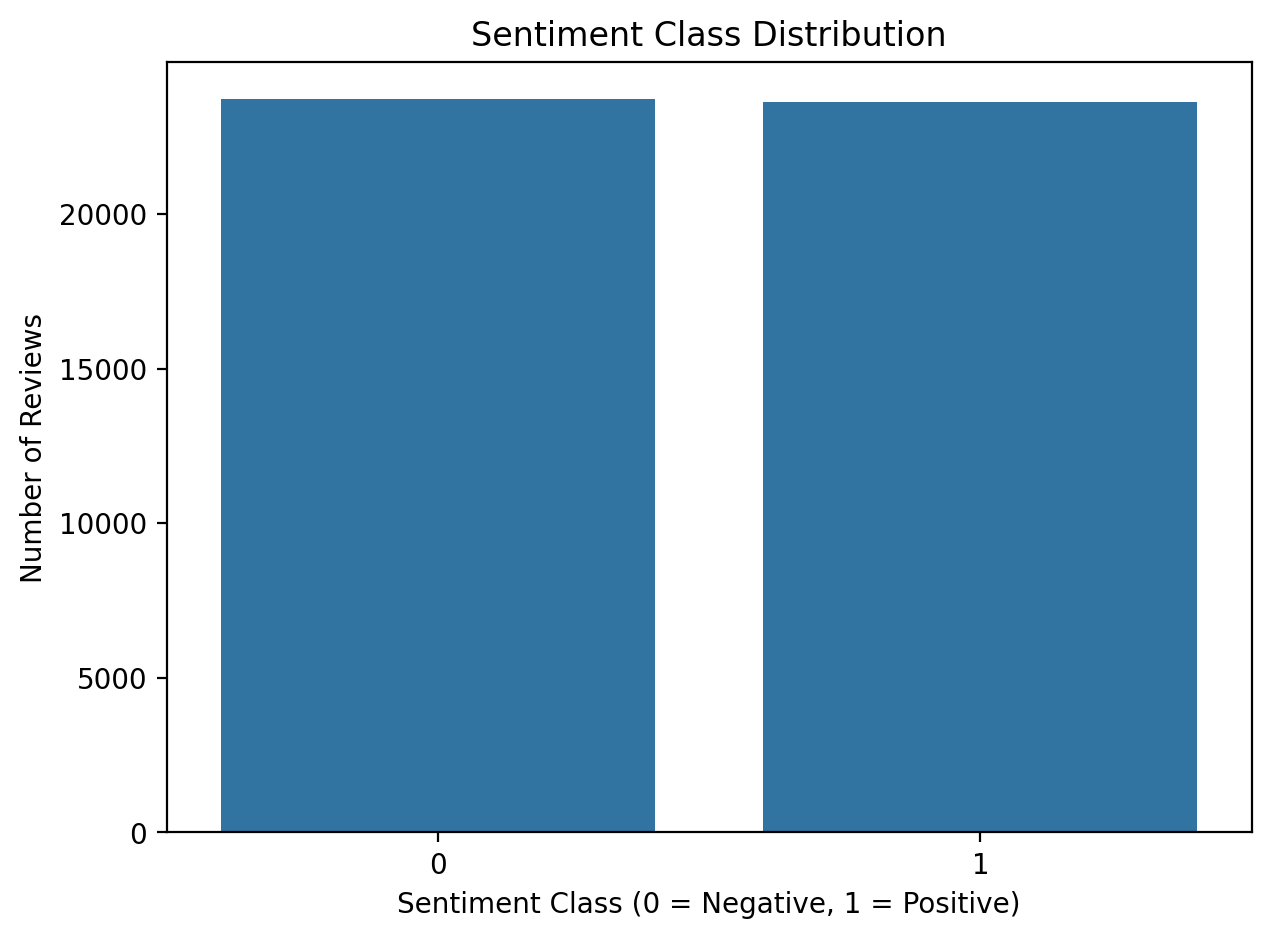

In [130]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df_reviews, x='pos')

plt.title('Sentiment Class Distribution')
plt.xlabel('Sentiment Class (0 = Negative, 1 = Positive)')
plt.ylabel('Number of Reviews')

plt.show()

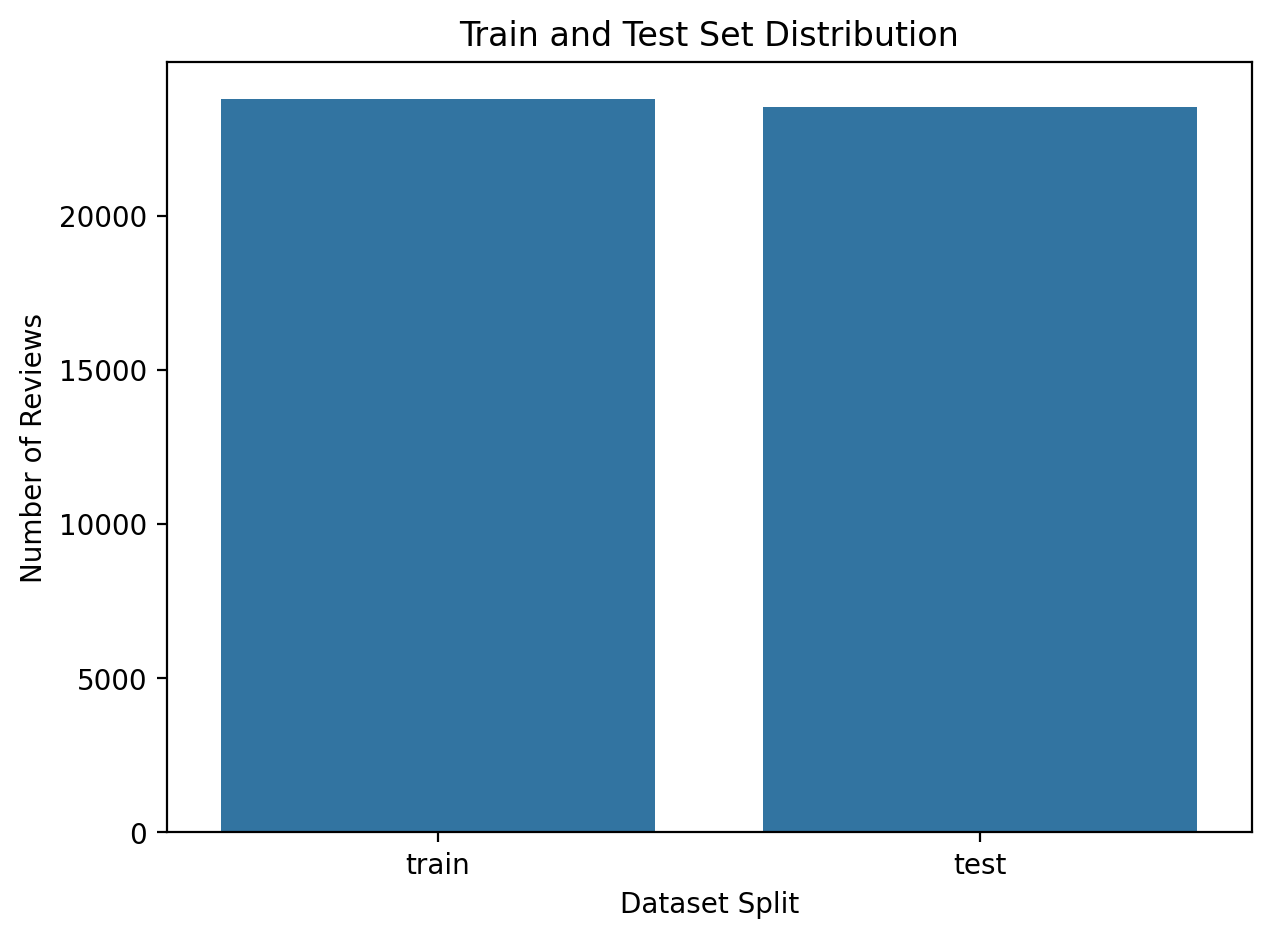

In [131]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df_reviews, x='ds_part')

plt.title('Train and Test Set Distribution')
plt.xlabel('Dataset Split')
plt.ylabel('Number of Reviews')

plt.show()

## Exploratory Data Analysis

### Movies and Reviews Over Time

This analysis examines how the number of movies and reviews changes over time, including the distribution of positive and negative reviews and the average number of reviews per movie.

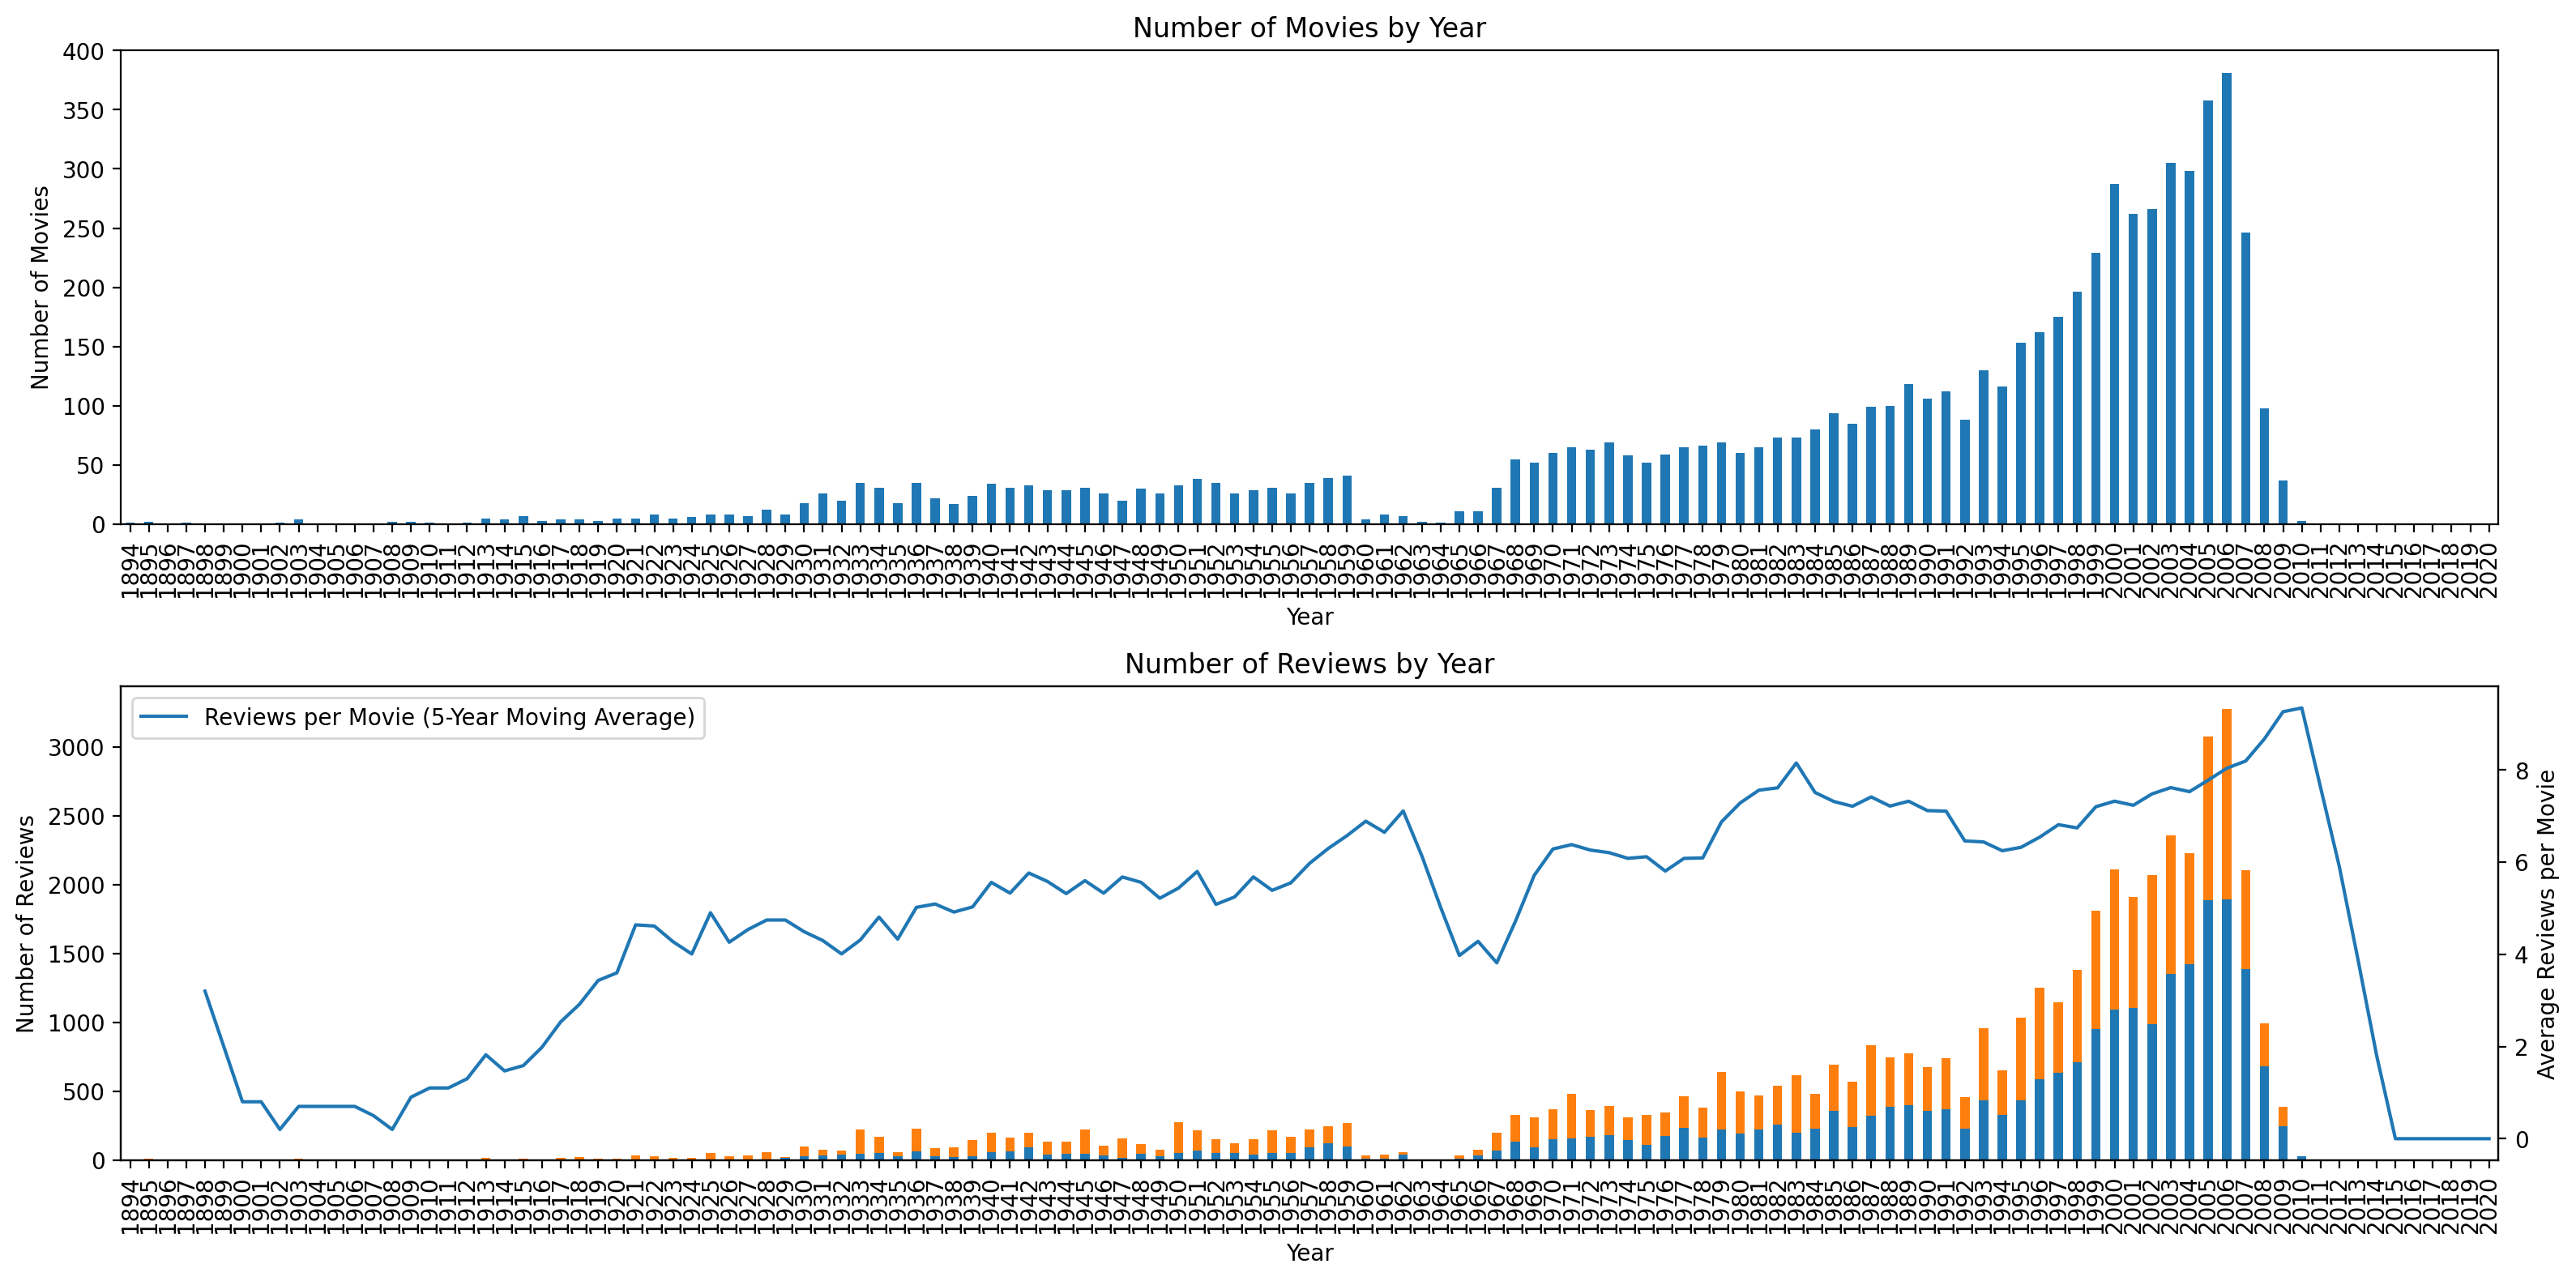

In [132]:
fig, axs = plt.subplots(2, 1, figsize=(16, 8))

# Number of movies by year
ax = axs[0]

dft1 = (
    df_reviews[['tconst', 'start_year']]
    .drop_duplicates()['start_year']
    .value_counts()
    .sort_index()
)

dft1 = dft1.reindex(
    index=np.arange(dft1.index.min(), max(dft1.index.max(), 2021))
).fillna(0)

dft1.plot(kind='bar', ax=ax)

ax.set_title('Number of Movies by Year')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Movies')


# Number of reviews by year and sentiment
ax = axs[1]

dft2 = df_reviews.groupby(['start_year', 'pos'])['pos'].count().unstack()

dft2 = dft2.reindex(
    index=np.arange(dft2.index.min(), max(dft2.index.max(), 2021))
).fillna(0)

dft2.plot(
    kind='bar',
    stacked=True,
    label='Reviews (Negative, Positive)',
    ax=ax
)

# Average number of reviews per movie
reviews_by_year = df_reviews['start_year'].value_counts().sort_index()

reviews_by_year = reviews_by_year.reindex(
    index=np.arange(
        reviews_by_year.index.min(),
        max(reviews_by_year.index.max(), 2021)
    )
).fillna(0)

reviews_per_movie = (reviews_by_year / dft1).fillna(0)

axt = ax.twinx()

reviews_per_movie.reset_index(drop=True).rolling(5).mean().plot(
    label='Reviews per Movie (5-Year Moving Average)',
    ax=axt
)

lines, labels = axt.get_legend_handles_labels()
ax.legend(lines, labels, loc='upper left')

ax.set_title('Number of Reviews by Year')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Reviews')
axt.set_ylabel('Average Reviews per Movie')

fig.tight_layout()
plt.show()

### Distribution of Reviews per Movie

The distribution of the number of reviews per movie is examined using both exact counts and a Kernel Density Estimate (KDE). The KDE provides a smoother view of the distribution and helps reveal its overall shape.

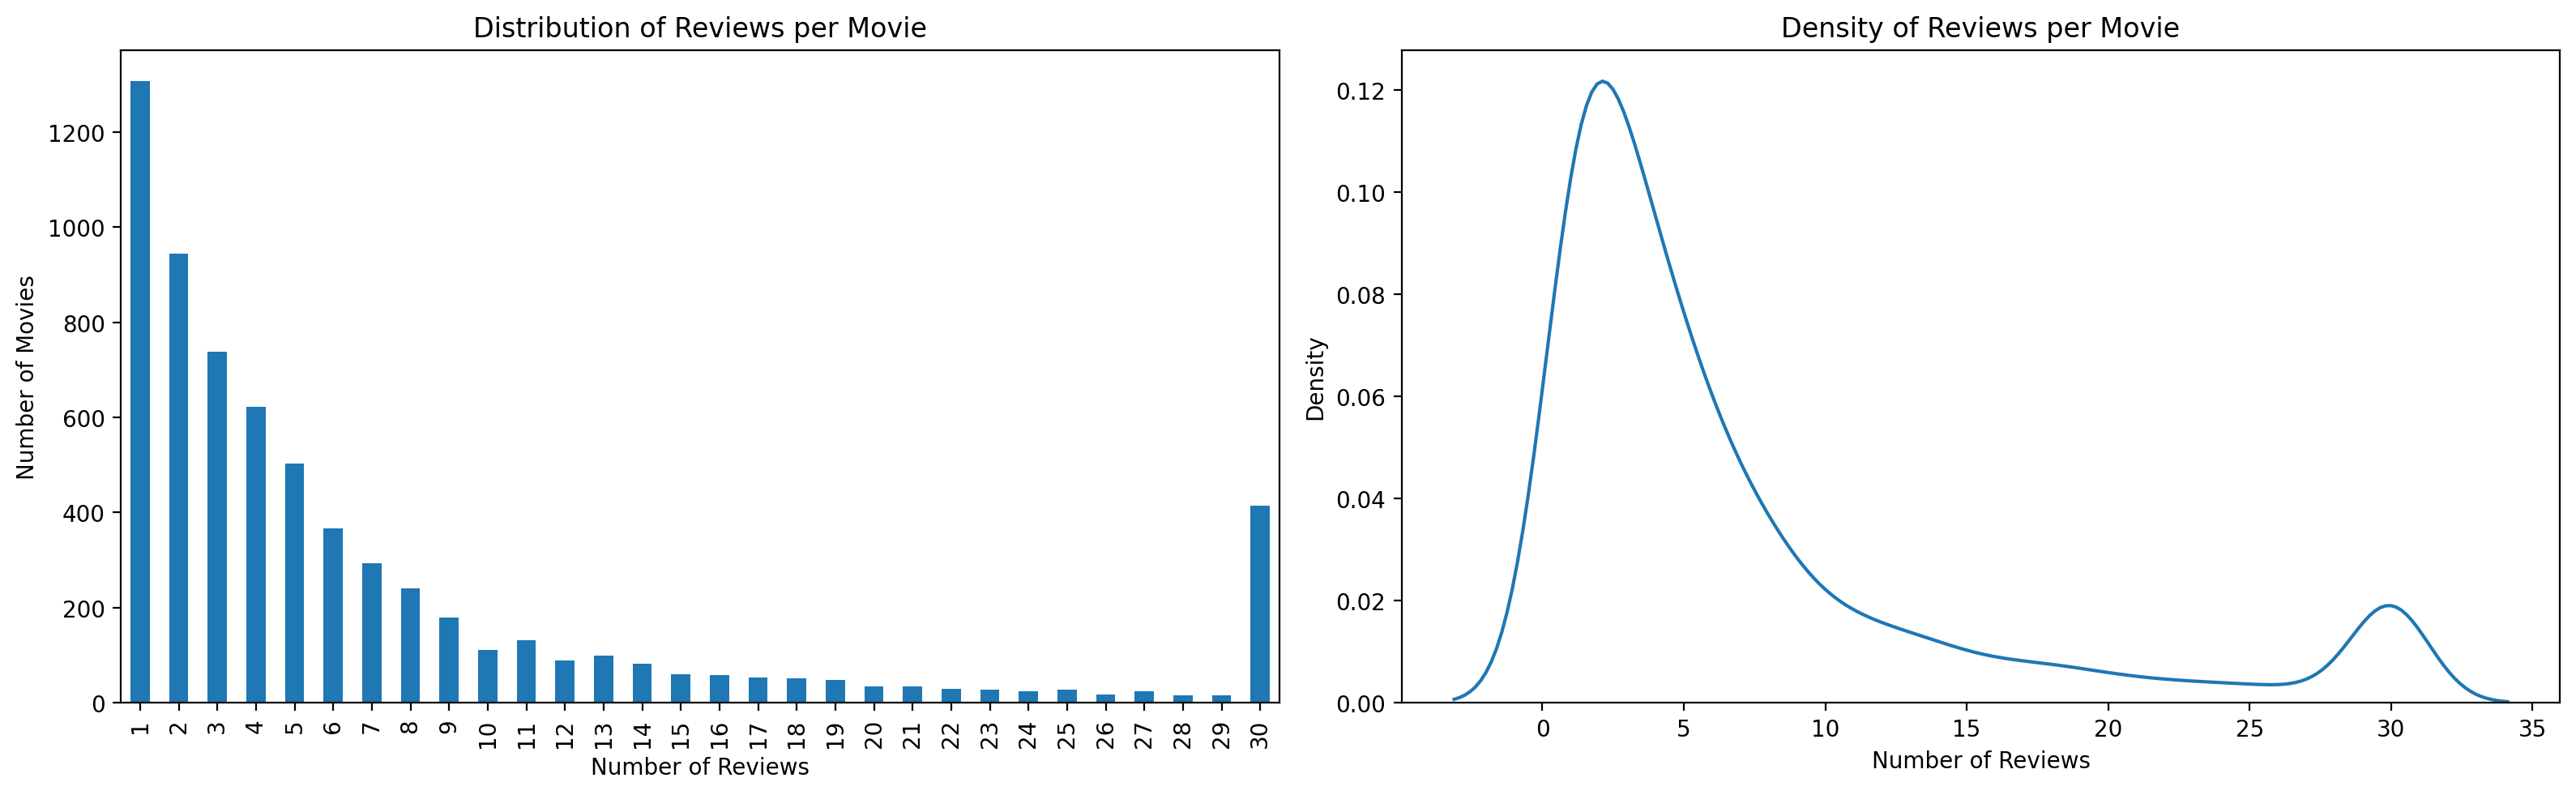

In [133]:
fig, axs = plt.subplots(1, 2, figsize=(16, 5))

# Number of reviews per movie
reviews_per_movie = df_reviews.groupby('tconst')['review'].count()

# Bar chart
ax = axs[0]

reviews_per_movie.value_counts().sort_index().plot.bar(ax=ax)

ax.set_title('Distribution of Reviews per Movie')
ax.set_xlabel('Number of Reviews')
ax.set_ylabel('Number of Movies')

# Density plot
ax = axs[1]

sns.kdeplot(reviews_per_movie, ax=ax)

ax.set_title('Density of Reviews per Movie')
ax.set_xlabel('Number of Reviews')
ax.set_ylabel('Density')

fig.tight_layout()
plt.show()

### Rating Distribution: Training vs. Test Sets

The rating distributions of the training and test sets are compared to verify that both subsets have similar patterns before model development.

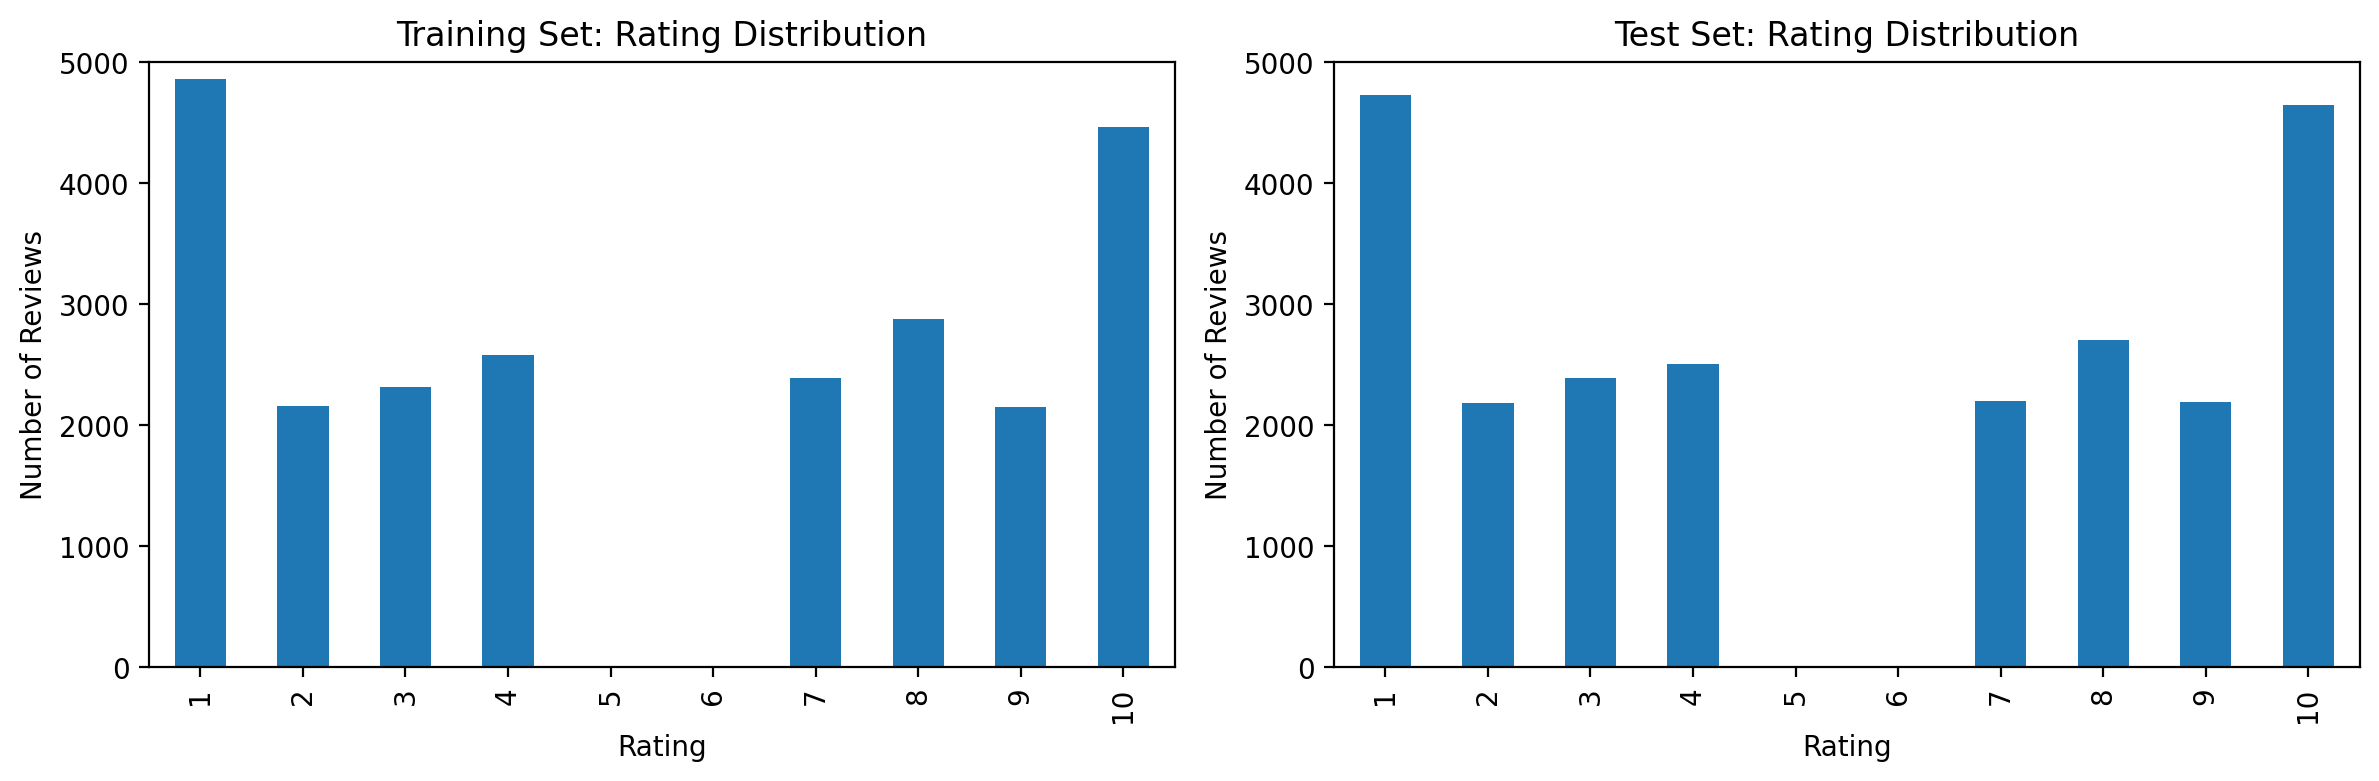

In [134]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

# Training set
ax = axs[0]

train_ratings = (
    df_reviews.query('ds_part == "train"')['rating']
    .value_counts()
    .sort_index()
)

train_ratings = train_ratings.reindex(
    index=np.arange(
        min(train_ratings.index.min(), 1),
        max(train_ratings.index.max(), 11)
    )
).fillna(0)

train_ratings.plot.bar(ax=ax)

ax.set_ylim([0, 5000])
ax.set_title('Training Set: Rating Distribution')
ax.set_xlabel('Rating')
ax.set_ylabel('Number of Reviews')


# Test set
ax = axs[1]

test_ratings = (
    df_reviews.query('ds_part == "test"')['rating']
    .value_counts()
    .sort_index()
)

test_ratings = test_ratings.reindex(
    index=np.arange(
        min(test_ratings.index.min(), 1),
        max(test_ratings.index.max(), 11)
    )
).fillna(0)

test_ratings.plot.bar(ax=ax)

ax.set_ylim([0, 5000])
ax.set_title('Test Set: Rating Distribution')
ax.set_xlabel('Rating')
ax.set_ylabel('Number of Reviews')

fig.tight_layout()
plt.show()

### Sentiment Distribution Across Training and Test Sets

The distribution of positive and negative reviews is compared across the training and test sets, both over time and across individual movies. This helps verify whether sentiment patterns remain consistent between the two subsets.

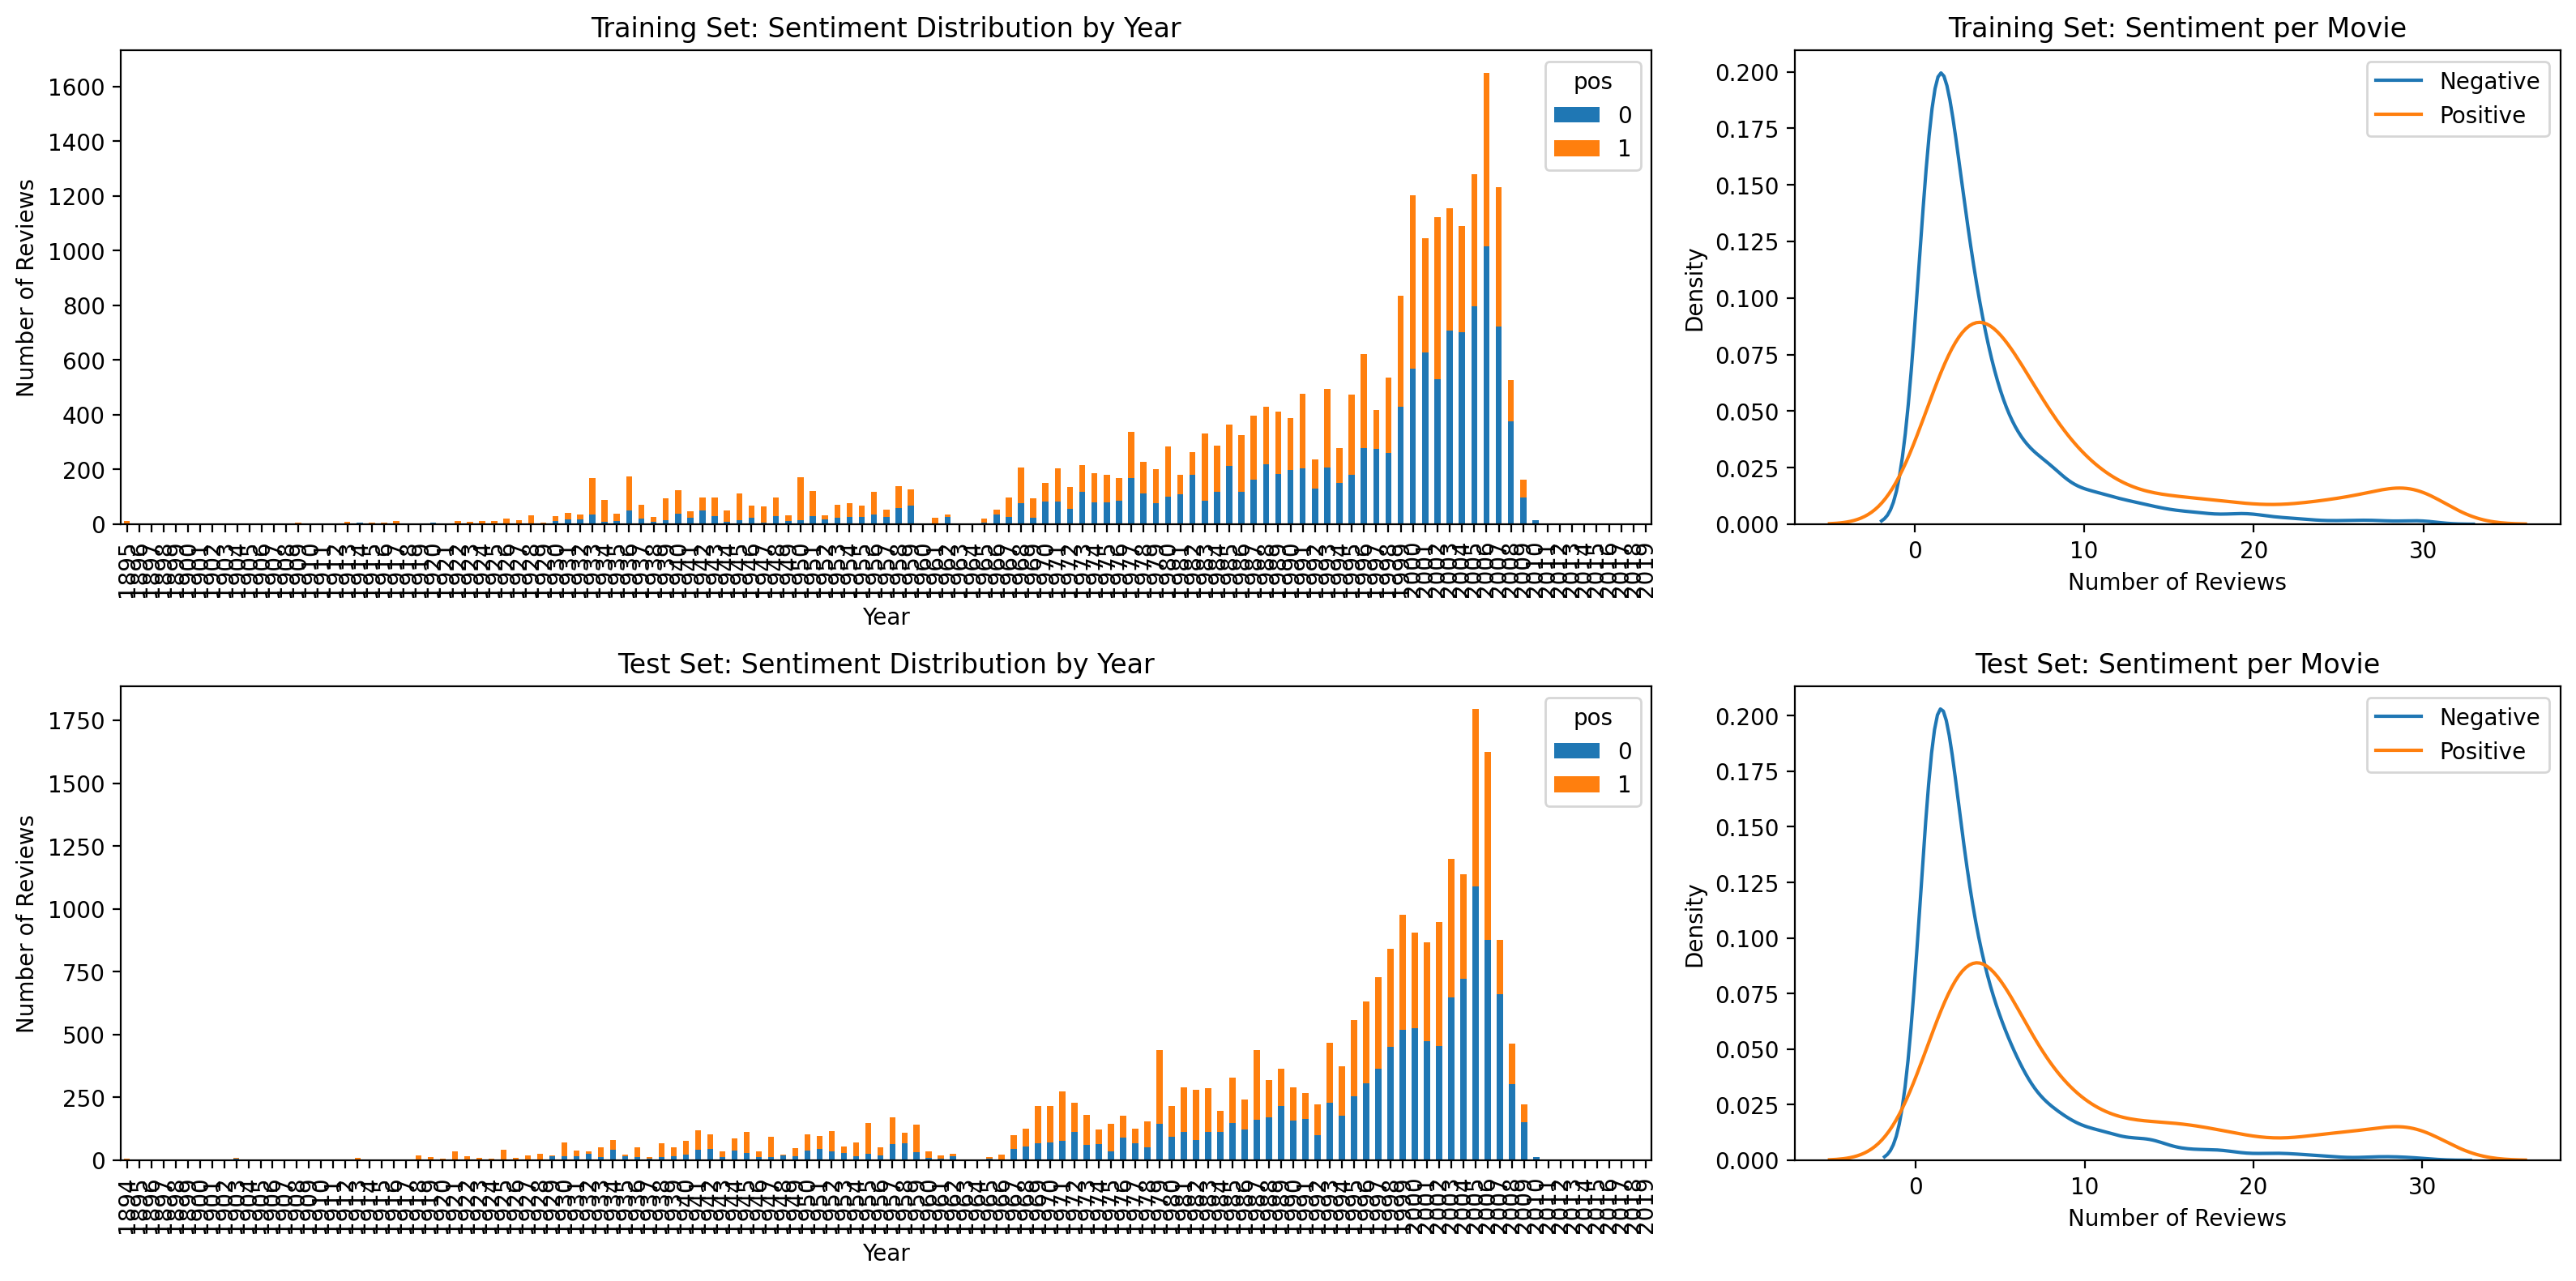

In [135]:
fig, axs = plt.subplots(
    2, 2,
    figsize=(16, 8),
    gridspec_kw={'width_ratios': (2, 1)}
)

# Training set: sentiment distribution by year
ax = axs[0, 0]

train_year = (
    df_reviews.query('ds_part == "train"')
    .groupby(['start_year', 'pos'])['pos']
    .count()
    .unstack()
)

train_year.index = train_year.index.astype(int)

train_year = train_year.reindex(
    index=np.arange(
        train_year.index.min(),
        max(train_year.index.max(), 2020)
    )
).fillna(0)

train_year.plot(kind='bar', stacked=True, ax=ax)

ax.set_title('Training Set: Sentiment Distribution by Year')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Reviews')


# Training set: sentiment distribution per movie
ax = axs[0, 1]

train_movie = (
    df_reviews.query('ds_part == "train"')
    .groupby(['tconst', 'pos'])['pos']
    .count()
    .unstack()
)

sns.kdeplot(train_movie[0].dropna(), label='Negative', ax=ax)
sns.kdeplot(train_movie[1].dropna(), label='Positive', ax=ax)

ax.legend()
ax.set_title('Training Set: Sentiment per Movie')
ax.set_xlabel('Number of Reviews')


# Test set: sentiment distribution by year
ax = axs[1, 0]

test_year = (
    df_reviews.query('ds_part == "test"')
    .groupby(['start_year', 'pos'])['pos']
    .count()
    .unstack()
)

test_year.index = test_year.index.astype(int)

test_year = test_year.reindex(
    index=np.arange(
        test_year.index.min(),
        max(test_year.index.max(), 2020)
    )
).fillna(0)

test_year.plot(kind='bar', stacked=True, ax=ax)

ax.set_title('Test Set: Sentiment Distribution by Year')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Reviews')


# Test set: sentiment distribution per movie
ax = axs[1, 1]

test_movie = (
    df_reviews.query('ds_part == "test"')
    .groupby(['tconst', 'pos'])['pos']
    .count()
    .unstack()
)

sns.kdeplot(test_movie[0].dropna(), label='Negative', ax=ax)
sns.kdeplot(test_movie[1].dropna(), label='Positive', ax=ax)

ax.legend()
ax.set_title('Test Set: Sentiment per Movie')
ax.set_xlabel('Number of Reviews')

fig.tight_layout()
plt.show()

## Model Evaluation

The following evaluation function is used consistently across all models to compare classification performance on the training and test sets.

In [136]:

import sklearn.metrics as metrics

def evaluate_model(
    model,
    train_features,
    train_target,
    test_features,
    test_target
):
    eval_stats = {}

    fig, axs = plt.subplots(1, 3, figsize=(20, 6))

    datasets = (
        ('train', train_features, train_target),
        ('test', test_features, test_target)
    )

    for split_name, features, target in datasets:

        eval_stats[split_name] = {}

        pred_target = model.predict(features)
        pred_proba = model.predict_proba(features)[:, 1]

        # F1 score across classification thresholds
        f1_thresholds = np.arange(0, 1.01, 0.05)
        f1_scores = [
            metrics.f1_score(
                target,
                pred_proba >= threshold,
                zero_division=0
            )
            for threshold in f1_thresholds
        ]

        # ROC curve
        fpr, tpr, roc_thresholds = metrics.roc_curve(
            target,
            pred_proba
        )

        roc_auc = metrics.roc_auc_score(
            target,
            pred_proba
        )

        eval_stats[split_name]['ROC AUC'] = roc_auc

        # Precision-Recall curve
        precision, recall, pr_thresholds = (
            metrics.precision_recall_curve(
                target,
                pred_proba
            )
        )

        aps = metrics.average_precision_score(
            target,
            pred_proba
        )

        eval_stats[split_name]['APS'] = aps

        color = 'blue' if split_name == 'train' else 'green'

        # F1 plot
        ax = axs[0]

        max_f1_score_idx = np.argmax(f1_scores)

        ax.plot(
            f1_thresholds,
            f1_scores,
            color=color,
            label=(
                f'{split_name}, '
                f'max={f1_scores[max_f1_score_idx]:.2f} '
                f'@ {f1_thresholds[max_f1_score_idx]:.2f}'
            )
        )

        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(
                np.abs(f1_thresholds - threshold)
            )

            marker_color = (
                'orange' if threshold != 0.5 else 'red'
            )

            ax.plot(
                f1_thresholds[closest_value_idx],
                f1_scores[closest_value_idx],
                color=marker_color,
                marker='X',
                markersize=7
            )

        ax.set_xlim([-0.02, 1.02])
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('Threshold')
        ax.set_ylabel('F1 Score')
        ax.legend(loc='lower center')
        ax.set_title('F1 Score by Threshold')

        # ROC plot
        ax = axs[1]

        ax.plot(
            fpr,
            tpr,
            color=color,
            label=f'{split_name}, ROC AUC={roc_auc:.2f}'
        )

        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(
                np.abs(roc_thresholds - threshold)
            )

            marker_color = (
                'orange' if threshold != 0.5 else 'red'
            )

            ax.plot(
                fpr[closest_value_idx],
                tpr[closest_value_idx],
                color=marker_color,
                marker='X',
                markersize=7
            )

        ax.plot([0, 1], [0, 1], linestyle='--')

        ax.set_xlim([-0.02, 1.02])
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('False Positive Rate')
        ax.set_ylabel('True Positive Rate')
        ax.legend(loc='lower center')
        ax.set_title('ROC Curve')

        # Precision-Recall plot
        ax = axs[2]

        ax.plot(
            recall,
            precision,
            color=color,
            label=f'{split_name}, AP={aps:.2f}'
        )

        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(
                np.abs(pr_thresholds - threshold)
            )

            marker_color = (
                'orange' if threshold != 0.5 else 'red'
            )

            ax.plot(
                recall[closest_value_idx],
                precision[closest_value_idx],
                color=marker_color,
                marker='X',
                markersize=7
            )

        ax.set_xlim([-0.02, 1.02])
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('Recall')
        ax.set_ylabel('Precision')
        ax.legend(loc='lower center')
        ax.set_title('Precision-Recall Curve')

        eval_stats[split_name]['Accuracy'] = (
            metrics.accuracy_score(
                target,
                pred_target
            )
        )

        eval_stats[split_name]['F1'] = (
            metrics.f1_score(
                target,
                pred_target
            )
        )

    df_eval_stats = pd.DataFrame(eval_stats).round(2)

    df_eval_stats = df_eval_stats.reindex(
        index=('Accuracy', 'F1', 'APS', 'ROC AUC')
    )

    print(df_eval_stats)

    plt.tight_layout()
    plt.show()

## Text Preprocessing

The review text is normalized before feature extraction by converting it to lowercase, removing unnecessary characters, and standardizing whitespace.

In [137]:
def clear_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z']", " ", text)
    text = " ".join(text.split())
    return text

In [138]:
df_reviews['review_norm'] = df_reviews['review'].progress_apply(clear_text)

  0%|          | 0/47331 [00:00<?, ?it/s]

In [139]:
df_reviews[['review', 'review_norm']].head()

,review,review_norm
0,The pakage implies that Warren Beatty and Gold...,the pakage implies that warren beatty and gold...
1,How the hell did they get this made?! Presenti...,how the hell did they get this made presenting...
2,There is no real story the film seems more lik...,there is no real story the film seems more lik...
3,Um .... a serious film about troubled teens in...,um a serious film about troubled teens in sing...
4,I'm totally agree with GarryJohal from Singapo...,i'm totally agree with garryjohal from singapo...


## Train and Test Sets

### Dataset Split

The dataset already includes predefined training and test partitions. These subsets are separated using the `ds_part` column to preserve the original split and ensure consistent model evaluation.

In [140]:
df_reviews_train = df_reviews.query('ds_part == "train"').copy()
df_reviews_test = df_reviews.query('ds_part == "test"').copy()

train_target = df_reviews_train['pos']
test_target = df_reviews_test['pos']

print(f'Training set: {df_reviews_train.shape}')
print(f'Test set: {df_reviews_test.shape}')

Training set: (23796, 18)
Test set: (23535, 18)


## Model Development

### Baseline Model

A simple baseline classifier is evaluated first to establish a reference performance level. The machine learning models developed afterward should outperform this baseline.

In [141]:
from sklearn.dummy import DummyClassifier

In [142]:
model_0 = DummyClassifier(strategy='most_frequent')

model_0.fit(
    np.zeros((len(train_target), 1)),
    train_target
);

          train  test
Accuracy    0.5   0.5
F1          0.0   0.0
APS         0.5   0.5
ROC AUC     0.5   0.5


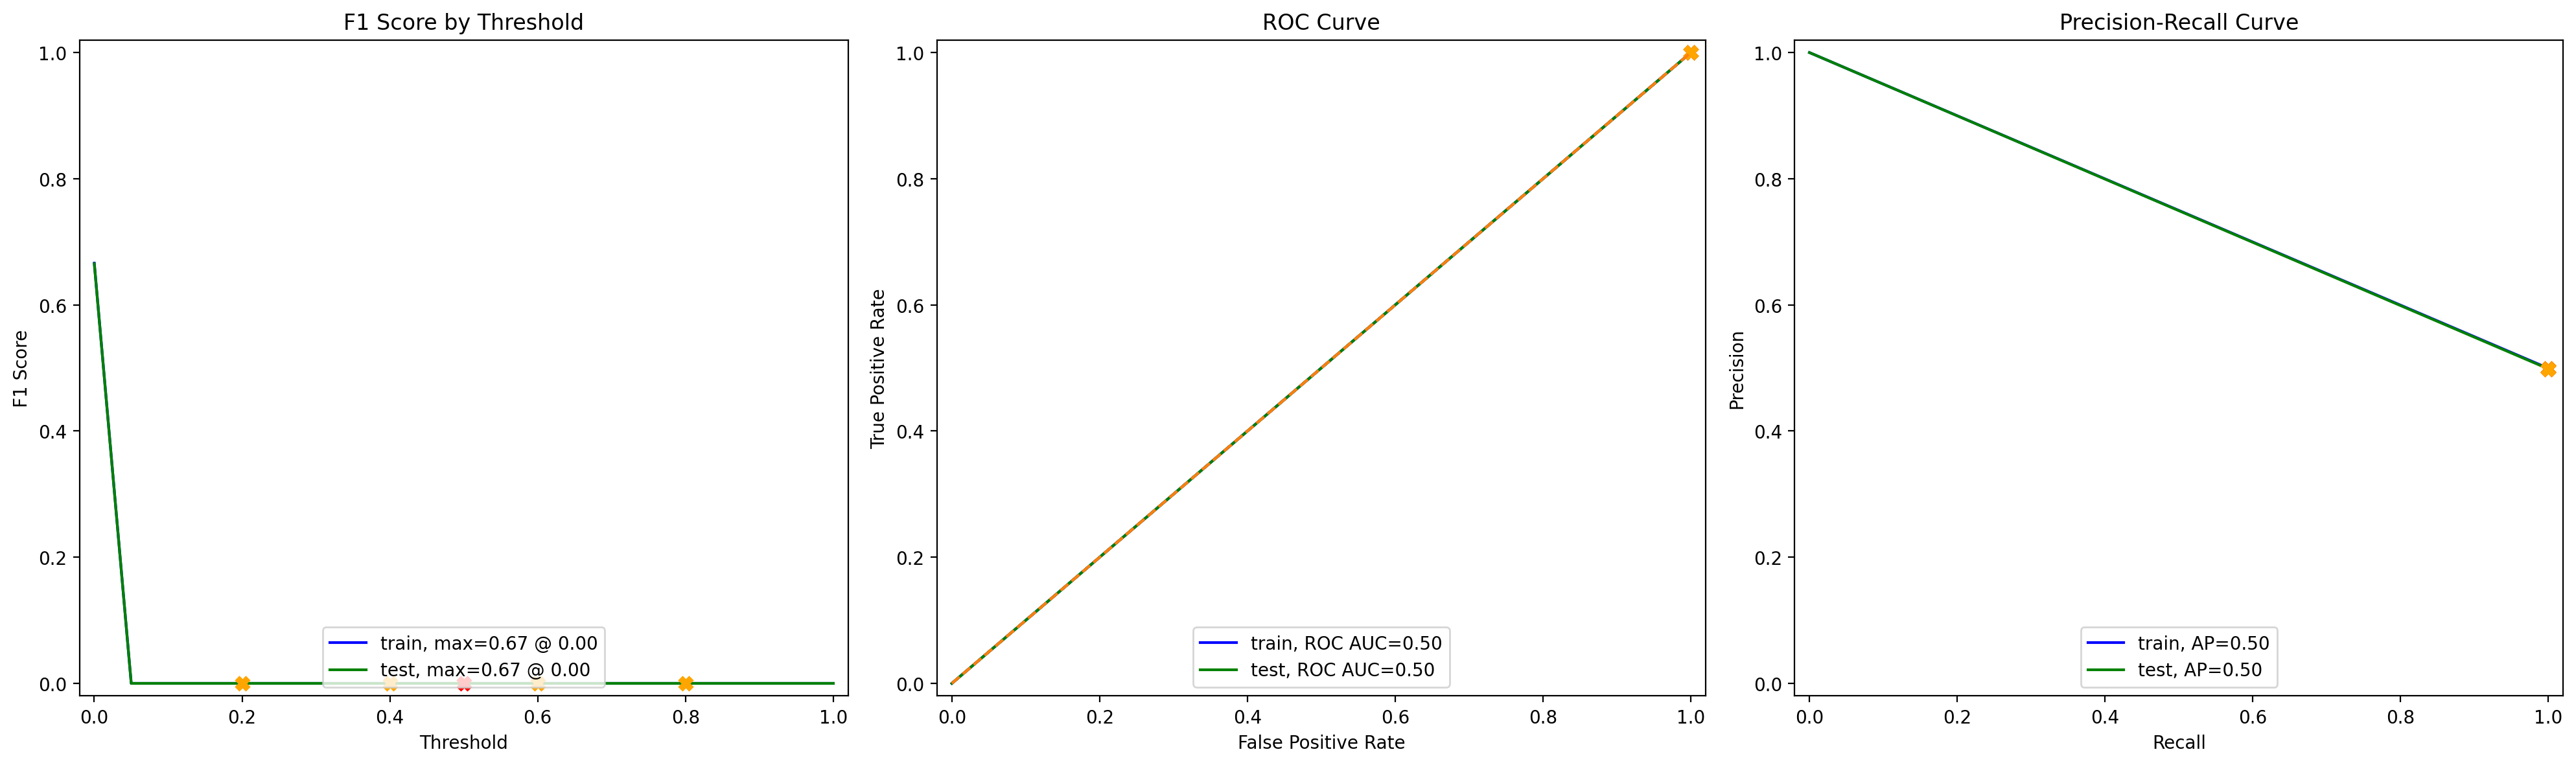

In [143]:
evaluate_model(
    model_0,
    np.zeros((len(train_target), 1)),
    train_target,
    np.zeros((len(test_target), 1)),
    test_target
)

**Baseline Result:** The dummy classifier achieves 50% accuracy and a ROC AUC of 0.50, which is equivalent to chance-level performance on this balanced dataset. This establishes the minimum benchmark that the trained sentiment classification models should outperform.

### Model 1 — TF-IDF + Logistic Regression


TF-IDF is used to transform the normalized review text into numerical features. A Logistic Regression classifier is then trained to predict whether each movie review expresses positive or negative sentiment.

In [144]:
stop_words = list(nltk_stopwords.words('english'))

tfidf_vectorizer_1 = TfidfVectorizer(stop_words=stop_words)

train_features_1 = tfidf_vectorizer_1.fit_transform(
    df_reviews_train['review_norm']
)

test_features_1 = tfidf_vectorizer_1.transform(
    df_reviews_test['review_norm']
)

In [145]:
model_1 = LogisticRegression(
    random_state=12345,
    max_iter=1000
)

model_1.fit(train_features_1, train_target);

          train  test
Accuracy   0.94  0.88
F1         0.94  0.88
APS        0.98  0.95
ROC AUC    0.98  0.95


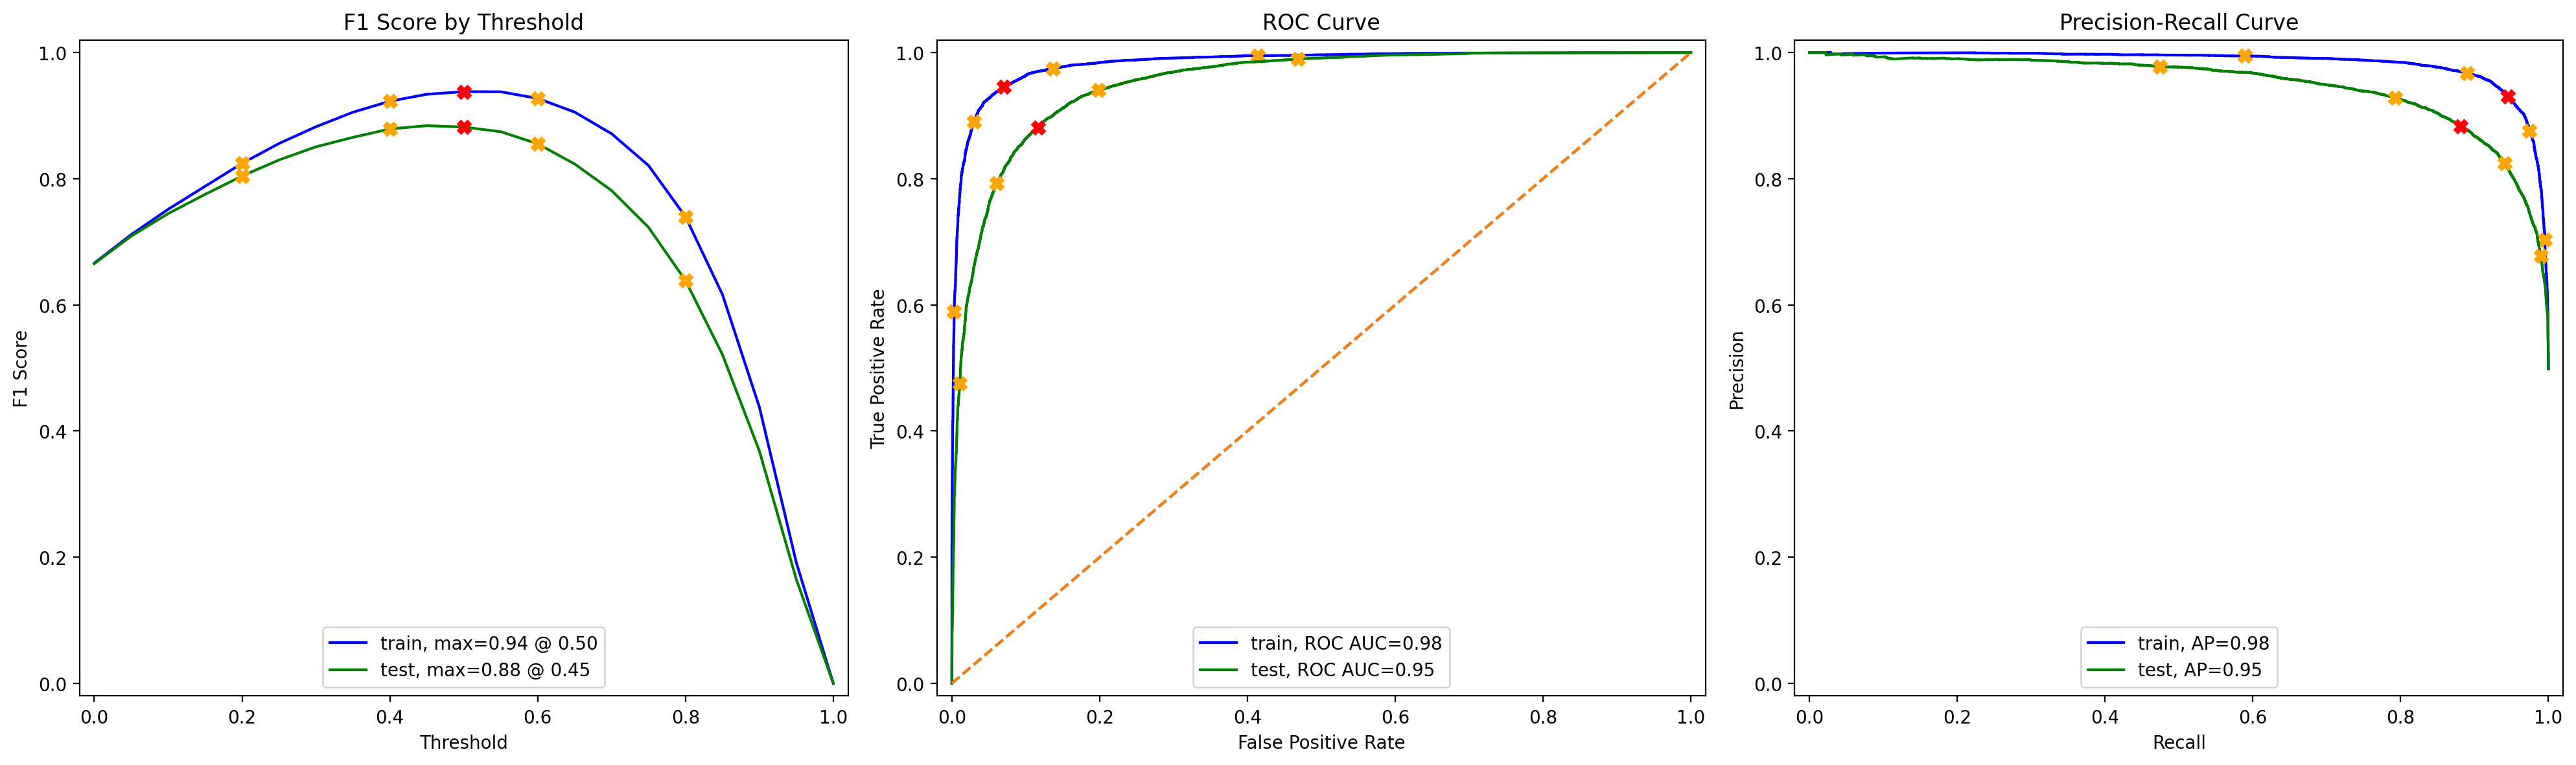

In [146]:
evaluate_model(model_1, train_features_1, train_target, test_features_1, test_target)

**Model 1 Result:** TF-IDF with Logistic Regression achieved an F1 score of **0.88** and a ROC AUC of **0.95** on the test set, substantially outperforming the baseline classifier and exceeding the project's target F1 score of 0.85.

### Model 2 — spaCy + TF-IDF + Logistic Regression

This model extends the TF-IDF approach by using spaCy for text preprocessing and lemmatization. The processed text is transformed into TF-IDF features and classified using Logistic Regression.

In [147]:
import spacy

nlp = spacy.load(
    'en_core_web_sm',
    disable=['parser', 'ner']
)


In [148]:
def text_preprocessing_2(text):
    doc = nlp(text)
    tokens = [token.lemma_ for token in doc]
    
    return ' '.join(tokens)

In [149]:
df_reviews_train['review_lemm_2'] = (
    df_reviews_train['review_norm']
    .progress_apply(text_preprocessing_2)
)

df_reviews_test['review_lemm_2'] = (
    df_reviews_test['review_norm']
    .progress_apply(text_preprocessing_2)
)

  0%|          | 0/23796 [00:00<?, ?it/s]

  0%|          | 0/23535 [00:00<?, ?it/s]

In [150]:
tfidf_vectorizer_2 = TfidfVectorizer(stop_words=stop_words)

train_features_2 = tfidf_vectorizer_2.fit_transform(
    df_reviews_train['review_lemm_2']
)

test_features_2 = tfidf_vectorizer_2.transform(
    df_reviews_test['review_lemm_2']
)

In [151]:
model_2 = LogisticRegression(
    random_state=12345,
    max_iter=1000
)

model_2.fit(train_features_2, train_target);

          train  test
Accuracy   0.93  0.88
F1         0.93  0.88
APS        0.98  0.95
ROC AUC    0.98  0.95


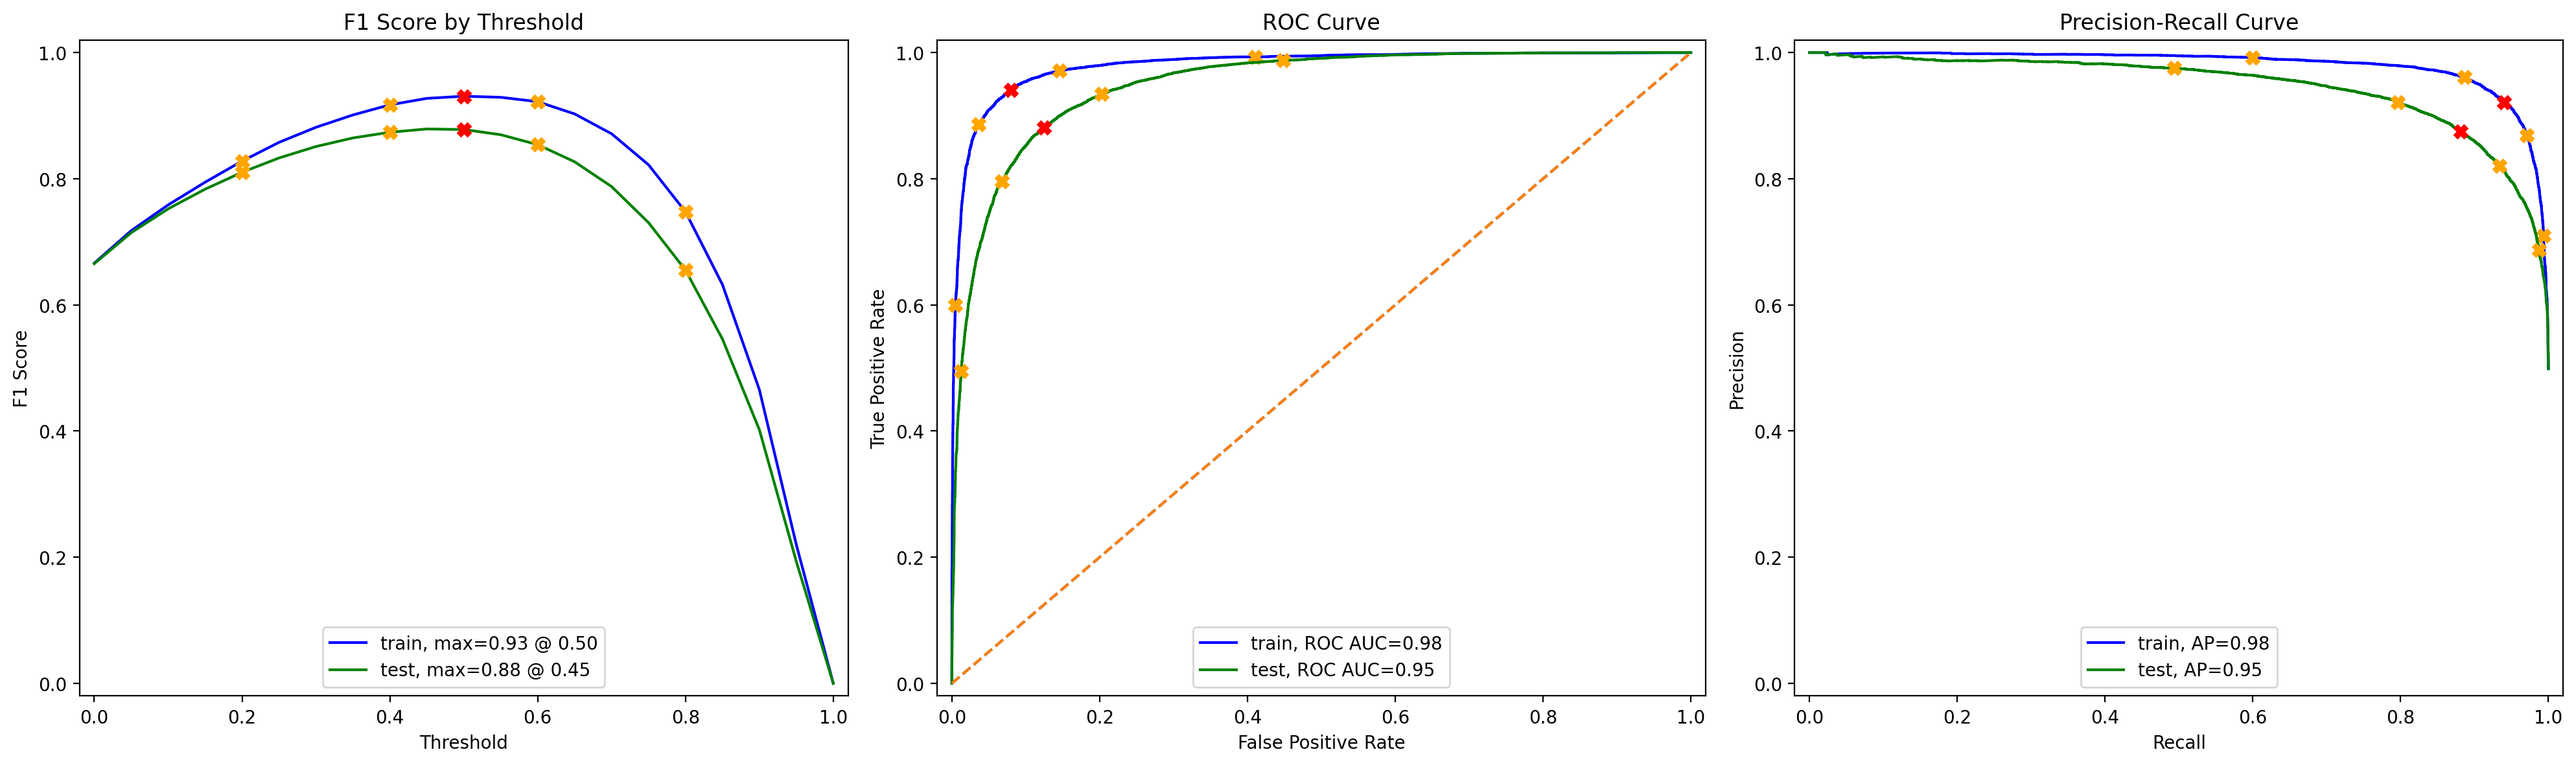

In [152]:
evaluate_model(
    model_2,
    train_features_2,
    train_target,
    test_features_2,
    test_target
)

**Model 2 Result:** The spaCy lemmatization + TF-IDF + Logistic Regression model achieved an F1 score of **0.88** and both APS and ROC AUC of **0.95** on the test set.

Its performance is nearly identical to Model 1, indicating that lemmatization did not provide a meaningful improvement for this dataset. Since Model 1 achieves comparable test performance with a simpler preprocessing pipeline, it remains the more efficient approach.

### Model 3 — spaCy + TF-IDF + LightGBM

This model uses the same spaCy-lemmatized TF-IDF features from Model 2, but replaces Logistic Regression with a LightGBM classifier. This allows us to compare a linear classification approach with a gradient boosting model using the same text representation.

In [153]:
from lightgbm import LGBMClassifier

In [154]:
model_3 = LGBMClassifier(random_state=12345, verbosity=-1)

model_3.fit(train_features_2, train_target);

          train  test
Accuracy   0.91  0.86
F1         0.92  0.86
APS        0.97  0.93
ROC AUC    0.97  0.94


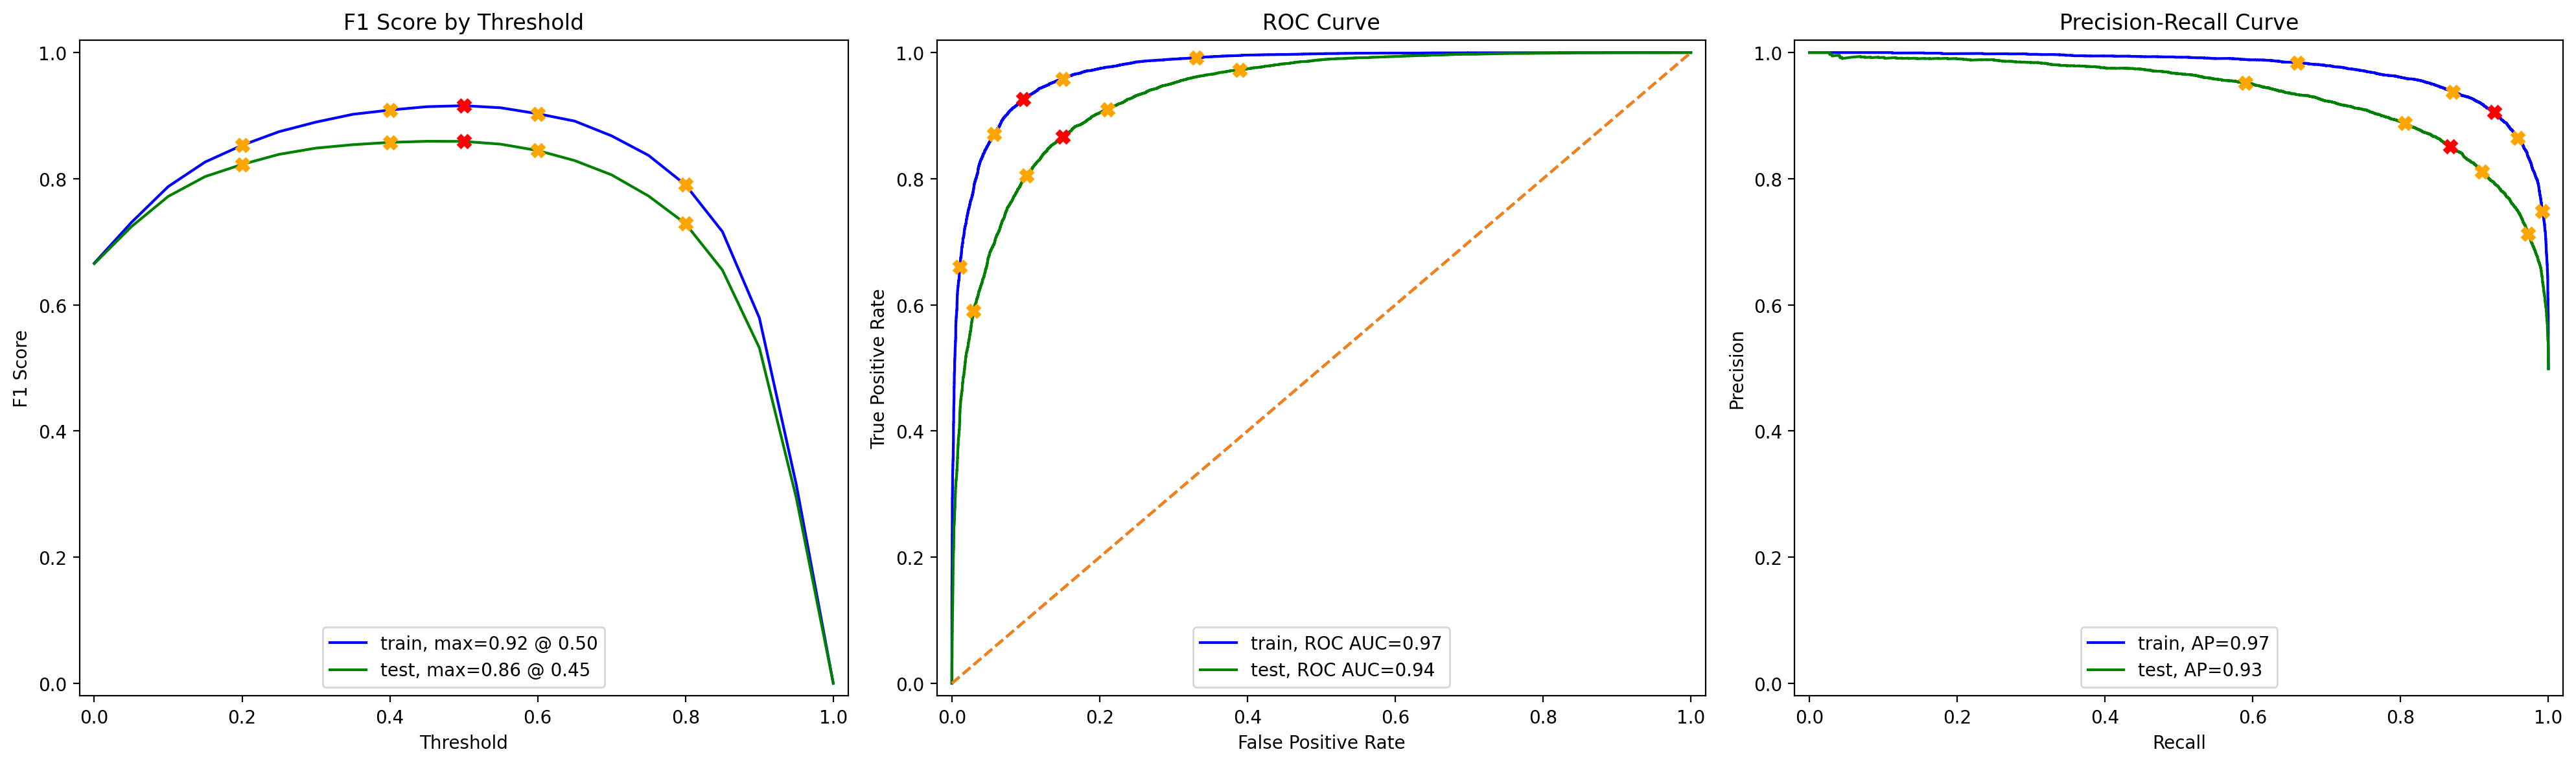

In [155]:
evaluate_model(
    model_3,
    train_features_2,
    train_target,
    test_features_2,
    test_target
)

### Model Comparison

The Logistic Regression models achieved the strongest performance, both reaching an F1 score of **0.88** on the test set and exceeding the project's minimum target of **0.85**.

Adding spaCy lemmatization did not produce a meaningful improvement compared with using normalized text alone. This indicates that the additional preprocessing complexity was not necessary for this dataset.

The LightGBM model also performed well, but its test performance was lower than that of the Logistic Regression models.

Overall, **TF-IDF + Logistic Regression** provided the best balance between predictive performance and model simplicity, making Model 1 the preferred approach for this sentiment classification task.

## Testing the Model on New Reviews

To demonstrate how the trained models perform on unseen text, I created a small set of custom movie reviews with different sentiment patterns. The models are used to estimate the probability that each review expresses positive sentiment.

In [156]:
my_reviews = pd.DataFrame([
    'This movie was absolutely fantastic. The acting was brilliant, the story was engaging, and I enjoyed every minute of it.',
    'One of the best films I have watched in years. Great performances, beautiful cinematography, and an unforgettable ending.',
    'I really wanted to like this movie, but it was boring and far too long. The plot was confusing and the acting felt weak.',
    'This was a complete waste of time. Terrible script, awful characters, and nothing interesting happened.',
    'The movie had some great moments, but it also had several boring scenes. Overall, it was okay but nothing special.',
    'The visuals were amazing, but the story was disappointing. I expected much more from this film.',
    'I could not stop laughing. The jokes were clever, the cast had great chemistry, and I would definitely watch it again.',
    'It started well, but the second half completely fell apart. The ending ruined what could have been a good movie.'
], columns=['review'])

my_reviews['review_norm'] = my_reviews['review'].apply(clear_text)


### Model 1

In [157]:
texts = my_reviews['review_norm']

my_reviews_pred_prob = model_1.predict_proba(
    tfidf_vectorizer_1.transform(texts)
)[:, 1]

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob[i]:.2f}: {review}')

0.93: this movie was absolutely fantastic the acting was brilliant the story was engaging and i enjoyed ev
0.99: one of the best films i have watched in years great performances beautiful cinematography and an unf
0.00: i really wanted to like this movie but it was boring and far too long the plot was confusing and the
0.00: this was a complete waste of time terrible script awful characters and nothing interesting happened
0.24: the movie had some great moments but it also had several boring scenes overall it was okay but nothi
0.53: the visuals were amazing but the story was disappointing i expected much more from this film
0.86: i could not stop laughing the jokes were clever the cast had great chemistry and i would definitely 
0.18: it started well but the second half completely fell apart the ending ruined what could have been a g


### Model 2

In [158]:
texts = my_reviews['review_norm']

lemmatized_texts = texts.apply(text_preprocessing_2)

my_reviews_pred_prob = model_2.predict_proba(
    tfidf_vectorizer_2.transform(lemmatized_texts)
)[:, 1]

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob[i]:.2f}: {review}')

0.85: this movie was absolutely fantastic the acting was brilliant the story was engaging and i enjoyed ev
0.99: one of the best films i have watched in years great performances beautiful cinematography and an unf
0.00: i really wanted to like this movie but it was boring and far too long the plot was confusing and the
0.00: this was a complete waste of time terrible script awful characters and nothing interesting happened
0.26: the movie had some great moments but it also had several boring scenes overall it was okay but nothi
0.58: the visuals were amazing but the story was disappointing i expected much more from this film
0.72: i could not stop laughing the jokes were clever the cast had great chemistry and i would definitely 
0.11: it started well but the second half completely fell apart the ending ruined what could have been a g


### Model 3

In [159]:
texts = my_reviews['review_norm']

lemmatized_texts = texts.apply(text_preprocessing_2)

my_reviews_pred_prob = model_3.predict_proba(
    tfidf_vectorizer_2.transform(lemmatized_texts)
)[:, 1]

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob[i]:.2f}: {review}')

0.81: this movie was absolutely fantastic the acting was brilliant the story was engaging and i enjoyed ev
0.94: one of the best films i have watched in years great performances beautiful cinematography and an unf
0.05: i really wanted to like this movie but it was boring and far too long the plot was confusing and the
0.03: this was a complete waste of time terrible script awful characters and nothing interesting happened
0.57: the movie had some great moments but it also had several boring scenes overall it was okay but nothi
0.61: the visuals were amazing but the story was disappointing i expected much more from this film
0.75: i could not stop laughing the jokes were clever the cast had great chemistry and i would definitely 
0.62: it started well but the second half completely fell apart the ending ruined what could have been a g


### Testing on Custom Reviews — Results

The three models were tested on a small set of custom reviews containing clearly positive, clearly negative, and mixed-sentiment examples.

The models produced confident probabilities for most clearly positive and negative reviews. Mixed-sentiment reviews resulted in less consistent predictions and probabilities closer to the decision boundary, highlighting the greater difficulty of classifying text that contains both praise and criticism.

Overall, the custom examples provide a practical demonstration of how the models behave on unseen text, while also showing that ambiguous sentiment remains more challenging to classify.

## Conclusion

In this project, a sentiment classification model was developed for Film Junky Union, a community for classic movie enthusiasts, with the goal of automatically identifying negative movie reviews.

The exploratory data analysis showed that the target classes were well balanced, with only a small number of missing values and no duplicated records.

The review text was normalized and transformed into numerical features using TF-IDF. Several approaches were evaluated, including a baseline classifier, Logistic Regression, and LightGBM. A second Logistic Regression model using spaCy lemmatization was also tested to evaluate whether additional text preprocessing could improve performance.

The best results were achieved by Logistic Regression, which reached an **F1 score of 0.88 on the test set**, exceeding the project's required minimum F1 score of **0.85**. Adding spaCy lemmatization did not provide a meaningful improvement, while LightGBM performed well but remained below the Logistic Regression models.

The models were also tested on a small set of custom reviews containing positive, negative, and mixed sentiment. Their predictions were generally consistent with the expected sentiment, providing an additional practical demonstration of their behavior on unseen text.

Overall, **TF-IDF combined with Logistic Regression provided the best balance between predictive performance and model simplicity**, making it the preferred approach for this sentiment classification task.